# 01 — Molecular Structure, HF, DFT & Basis Sets

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/01_molecular_structure_and_basis_sets.ipynb)

## 🎯 Learning Objectives


- Slater-type (STO) and Gaussian-type (GTO) orbitals/basis functions
- Basis set families and understand accuracy/cost trade-offs
- Basis set convergence for total energies
- Contracted vs primitive basis functions
- Effective core potentials (ECPs) and when to use them
- Atomic orbital radial probability distributions

## 1. Theory: Basis Functions in Quantum Chemistry

### 1.1 Slater-Type Orbitals (STOs)

The exact hydrogen-like atomic orbitals are Slater-type orbitals (STOs):

$$\chi_{nlm}(r,\theta,\phi) = N r^{n-1} e^{-\zeta r} Y_l^m(\theta,\phi)$$

where:
- $N$ = normalization constant
- $n$ = principal quantum number
- $\zeta$ (zeta) = orbital exponent controlling size
- $Y_l^m$ = spherical harmonic

**Advantages:** Correct cusp at nucleus, correct exponential decay
**Disadvantage:** Multi-center two-electron integrals are very expensive (no analytic formula)

### 1.2 Gaussian-Type Orbitals (GTOs)

In practice, we use Gaussian-type orbitals (GTOs):

$$g_{lmn}(\mathbf{r}; \alpha) = N x^l y^m z^n e^{-\alpha r^2}$$

where $\alpha$ is the Gaussian exponent and $l+m+n$ determines the angular momentum.

**Advantage:** Products of Gaussians are Gaussians → all integrals are analytic!
**Disadvantage:** Incorrect behavior at nucleus (no cusp) and at long range (decays too fast)

### 1.3 Contracted Basis Sets

To capture STO-like behavior, we use **contracted** basis functions:
$$\chi_\mu = \sum_k d_{k\mu} g_k$$

A **contraction** combines multiple primitive Gaussians ($g_k$) with fixed coefficients ($d_{k\mu}$) to form a single basis function. For example, STO-3G uses 3 Gaussians to approximate each STO.

### 1.4 Basis Set Families

| Family | Strategy | Example |
|--------|----------|---------|
| **Pople** | Add shells systematically | 6-31G, 6-31G\*, 6-311G\*\* |
| **Dunning** (cc-pVxZ) | Converges to CBS limit | cc-pVDZ, cc-pVTZ, cc-pVQZ |
| **Ahlrichs** (def2) | Balanced accuracy/cost | def2-SVP, def2-TZVP, def2-QZVP |

**Notation:**
- **DZ** (double-ζ), **TZ** (triple-ζ), **QZ** (quadruple-ζ): number of basis functions per orbital
- **\*** or **P**: adds polarization functions (e.g., d functions on C, N, O)
- **aug-**: adds diffuse functions (needed for anions, excited states, weak interactions)

In [1]:
# =============================================================================
# Ch121a: Quantum Chemistry & DFT — Notebook 01: Molecular Structure & Basis Sets
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyscf import gto, scf

  STO-3G        N=  7  E = -74.96293261 Ha
  3-21G         N= 13  E = -75.58539445 Ha
  6-31G*        N= 18  E = -76.00913108 Ha
  cc-pVDZ       N= 24  E = -76.02679684 Ha
  cc-pVTZ       N= 58  E = -76.05716610 Ha
  def2-SVP      N= 24  E = -75.96101285 Ha
  def2-TZVP     N= 43  E = -76.05904087 Ha


Basis Set  N_basis  E_HF (Ha)   E_HF (eV)
   STO-3G        7 -74.962933 -2039.84634
    3-21G       13 -75.585394 -2056.78440
   6-31G*       18 -76.009131 -2068.31487
  cc-pVDZ       24 -76.026797 -2068.79558
  cc-pVTZ       58 -76.057166 -2069.62197
 def2-SVP       24 -75.961013 -2067.00551
def2-TZVP       43 -76.059041 -2069.67298

cc-pVTZ - STO-3G energy difference: -686.64 kcal/mol


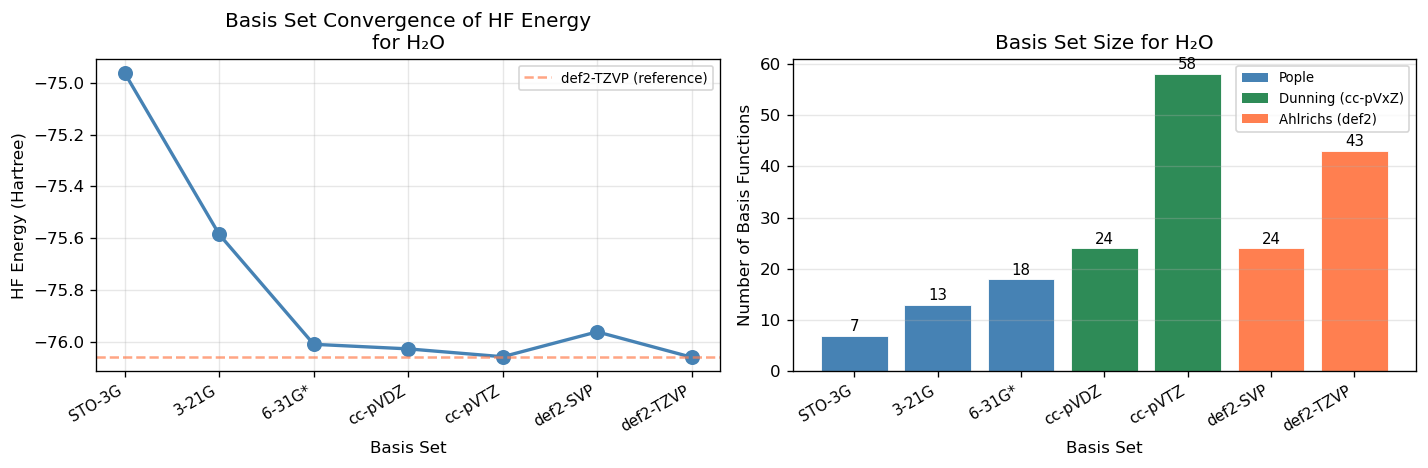

CPU times: user 11.6 s, sys: 60.6 ms, total: 11.6 s
Wall time: 3.54 s


In [2]:
%%time
# ------------------------------------------------------------------
# Basis set convergence study for water (H2O)
# ------------------------------------------------------------------
# We compare HF energies across a range of basis sets to see
# how the energy converges toward the complete basis set (CBS) limit.

mol_template = """
O   0.000000   0.000000   0.117176
H   0.000000   0.757001  -0.468704
H   0.000000  -0.757001  -0.468704
"""

basis_sets = ['STO-3G', '3-21G', '6-31G*', 'cc-pVDZ', 'cc-pVTZ', 'def2-SVP', 'def2-TZVP']

results = []
for basis in basis_sets:
    mol = gto.Mole()
    mol.atom = mol_template
    mol.basis = basis
    mol.verbose = 0
    mol.build()
    mf = scf.RHF(mol)
    mf.verbose = 0
    e = mf.kernel()
    n_bas = mol.nao_nr()
    results.append({'Basis Set': basis, 'N_basis': n_bas,
                    'E_HF (Ha)': round(e, 8), 'E_HF (eV)': round(e*27.2114, 5)})
    print(f"  {basis:12s}  N={n_bas:3d}  E = {e:.8f} Ha")

df = pd.DataFrame(results)
print("\n")
print(df.to_string(index=False))
print(f"\ncc-pVTZ - STO-3G energy difference: {(results[4]['E_HF (Ha)']-results[0]['E_HF (Ha)'])*627.509:.2f} kcal/mol")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

energies = [r['E_HF (Ha)'] for r in results]
n_basis = [r['N_basis'] for r in results]
labels = [r['Basis Set'] for r in results]

# Panel 1: Energy vs basis set
ax1.plot(range(len(basis_sets)), energies, 'o-', color='steelblue',
         linewidth=2, markersize=8)
ax1.axhline(y=energies[-1], color='coral', linestyle='--', alpha=0.7, label='def2-TZVP (reference)')
ax1.set_xticks(range(len(basis_sets)))
ax1.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax1.set_xlabel('Basis Set')
ax1.set_ylabel('HF Energy (Hartree)')
ax1.set_title('Basis Set Convergence of HF Energy\nfor H₂O')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# Panel 2: Number of basis functions vs basis set
colors = ['steelblue' if 'STO' in b or '3-21' in b or '6-31G*' in b else
          'seagreen' if 'cc-p' in b else 'coral' for b in labels]
bars = ax2.bar(range(len(basis_sets)), n_basis, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(len(basis_sets)))
ax2.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
ax2.set_xlabel('Basis Set')
ax2.set_ylabel('Number of Basis Functions')
ax2.set_title('Basis Set Size for H₂O')
ax2.grid(True, alpha=0.3, axis='y')
for bar, n in zip(bars, n_basis):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(n), ha='center', va='bottom', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Pople'),
                   Patch(facecolor='seagreen', label='Dunning (cc-pVxZ)'),
                   Patch(facecolor='coral', label='Ahlrichs (def2)')]
ax2.legend(handles=legend_elements, fontsize=8)

plt.tight_layout()
plt.show()

In [3]:
# ------------------------------------------------------------------
# Effective Core Potentials (ECPs)
# ------------------------------------------------------------------
# For heavy elements (3d, 4d, 5d transition metals, lanthanides),
# the core electrons are chemically inert and their relativistic
# effects can be captured via an ECP (pseudopotential).

from pyscf import gto

# Demonstrate ECP for Iron (Fe, Z=26)
mol_Fe = gto.Mole()
mol_Fe.atom = 'Fe 0 0 0'
mol_Fe.basis = 'def2-SVP'
mol_Fe.ecp = 'def2-SVP'     # Use the def2-SVP ECP for Fe
mol_Fe.verbose = 0
mol_Fe.build()

print("=" * 55)
print("  Effective Core Potential (ECP) Demonstration: Fe")
print("=" * 55)
print(f"  Element:                        Fe (Z = 26)")
print(f"  ECP:                            def2-SVP")
print(f"  Core electrons replaced by ECP: {mol_Fe.atom_nelec_core(0)}")
print(f"  Valence electrons treated:      {mol_Fe.nelectron}")
print(f"  Basis functions (valence only): {mol_Fe.nao_nr()}")

# Compare with all-electron def2-SVP (no ECP)
mol_Fe_ae = gto.Mole()
mol_Fe_ae.atom = 'Fe 0 0 0'
mol_Fe_ae.basis = 'def2-SVP'
mol_Fe_ae.verbose = 0
mol_Fe_ae.build()
print(f"\n  All-electron comparison:")
print(f"  All electrons:                  {mol_Fe_ae.nelectron}")
print(f"  Basis functions (all-electron): {mol_Fe_ae.nao_nr()}")

print("\nWhen to use ECPs:")
print("  • Elements beyond Kr (Z > 36): relativistic effects important")
print("  • 3d metals: saves ~10 core electrons per atom")
print("  • 4d/5d metals: saves ~28/60 core electrons per atom")
print("  • Lanthanides/Actinides: ECP is essentially mandatory")

  Effective Core Potential (ECP) Demonstration: Fe
  Element:                        Fe (Z = 26)
  ECP:                            def2-SVP
  Core electrons replaced by ECP: 0
  Valence electrons treated:      26
  Basis functions (valence only): 31

  All-electron comparison:
  All electrons:                  26
  Basis functions (all-electron): 31

When to use ECPs:
  • Elements beyond Kr (Z > 36): relativistic effects important
  • 3d metals: saves ~10 core electrons per atom
  • 4d/5d metals: saves ~28/60 core electrons per atom
  • Lanthanides/Actinides: ECP is essentially mandatory


ECP def2-SVP not found for  Fe


In [6]:
from pyscf import gto

# ── Mo (Z=42) ─ correctly uses def2-ECP ──────────────────────────
mol_Mo = gto.Mole()
mol_Mo.atom  = 'Mo 0 0 0'       # Bug fix 1: was 'Fe'
mol_Mo.basis = 'def2-SVP'
mol_Mo.ecp   = 'def2-SVP'       # PySCF accepts 'def2-SVP' or 'def2-ecp'
mol_Mo.spin  = 6                 # Mo ground state: [Kr] 4d5 5s1, S=3
mol_Mo.verbose = 0
mol_Mo.build()

print("=" * 55)
print("  ECP Demonstration: Mo (Z=42)")
print("=" * 55)
print(f"  ECP:                            def2-SVP")
print(f"  Core electrons replaced:        {mol_Mo.atom_nelec_core(0)}")  # → 28
print(f"  Valence electrons treated:      {mol_Mo.nelectron}")
print(f"  Basis functions (valence only): {mol_Mo.nao_nr()}")

# ── Fe (Z=26) ─ all-electron, no ECP needed ──────────────────────
mol_Fe_ae = gto.Mole()
mol_Fe_ae.atom    = 'Fe 0 0 0'
mol_Fe_ae.basis   = 'def2-SVP'   # NO mol.ecp line — all-electron
mol_Fe_ae.spin    = 4            # Fe ground state: [Ar] 3d6 4s2, S=2
mol_Fe_ae.verbose = 0
mol_Fe_ae.build()

print(f"\n  All-electron Fe (Z=26) with def2-SVP:")
print(f"  All electrons:                  {mol_Fe_ae.nelectron}")  # → 26
print(f"  Core electrons (ECP):           {mol_Fe_ae.atom_nelec_core(0)}")  # → 0
print(f"  Basis functions:                {mol_Fe_ae.nao_nr()}")

  ECP Demonstration: Mo (Z=42)
  ECP:                            def2-SVP
  Core electrons replaced:        28
  Valence electrons treated:      14
  Basis functions (valence only): 31

  All-electron Fe (Z=26) with def2-SVP:
  All electrons:                  26
  Core electrons (ECP):           0
  Basis functions:                31


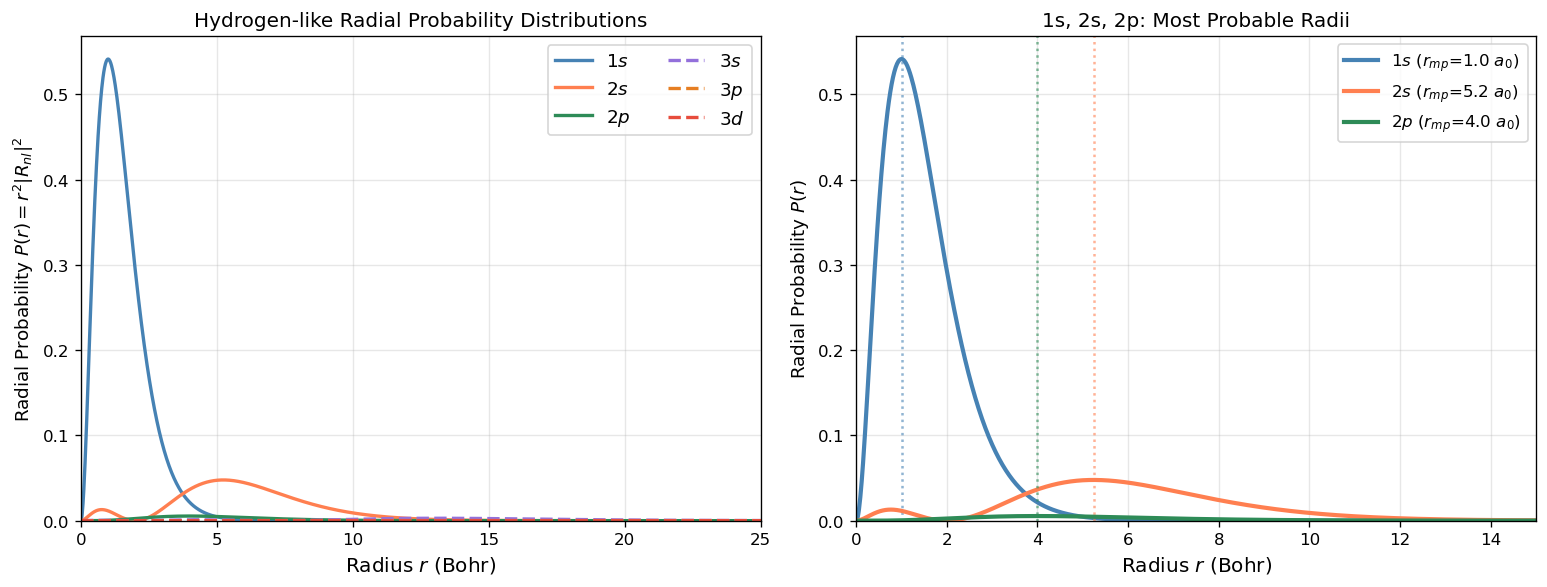


Note: 1 Bohr = 0.529 Å
Most probable radius for 1s: 1 Bohr (= Bohr radius a₀)


In [7]:
# ------------------------------------------------------------------
# Radial Probability Distributions of Hydrogen-like Orbitals
# ------------------------------------------------------------------
# P(r) = r^2 |R_nl(r)|^2  (probability per unit radius)

import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import factorial, genlaguerre

def hydrogen_radial(n, l, r, Z=1):
    """Normalized radial wavefunction R_nl(r) for hydrogen-like atom."""
    rho = 2 * Z * r / n
    # Normalization constant
    norm = np.sqrt((2*Z/n)**3 * factorial(n-l-1) /
                   (2*n * factorial(n+l)**3))
    # Associated Laguerre polynomial
    L = genlaguerre(n-l-1, 2*l+1)(rho)
    return norm * np.exp(-rho/2) * rho**l * L

r = np.linspace(0.001, 30, 2000)  # Bohr radii

orbitals = [
    (1, 0, '1s', 'steelblue',   '-'),
    (2, 0, '2s', 'coral',        '-'),
    (2, 1, '2p', 'seagreen',    '-'),
    (3, 0, '3s', 'mediumpurple', '--'),
    (3, 1, '3p', '#E67E22',      '--'),
    (3, 2, '3d', '#E74C3C',      '--'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left plot: all orbitals together
ax = axes[0]
for n, l, label, color, ls in orbitals:
    R = hydrogen_radial(n, l, r)
    P = r**2 * R**2
    ax.plot(r, P, label=f'${label}$', color=color, linestyle=ls, linewidth=2)
ax.set_xlim(0, 25)
ax.set_ylim(bottom=0)
ax.set_xlabel('Radius $r$ (Bohr)', fontsize=12)
ax.set_ylabel('Radial Probability $P(r) = r^2|R_{nl}|^2$', fontsize=11)
ax.set_title('Hydrogen-like Radial Probability Distributions', fontsize=12)
ax.legend(fontsize=11, ncol=2)
ax.grid(True, alpha=0.3)

# Right plot: n=1,2,3 s orbitals only (compare size)
ax2 = axes[1]
for n, l, label, color, ls in orbitals[:3]:
    R = hydrogen_radial(n, l, r)
    P = r**2 * R**2
    # Mark the most probable radius
    r_mp = r[np.argmax(P)]
    ax2.plot(r, P, label=f'${label}$ ($r_{{mp}}$={r_mp:.1f} $a_0$)',
             color=color, linewidth=2.5)
    ax2.axvline(x=r_mp, color=color, linestyle=':', alpha=0.6)
ax2.set_xlim(0, 15)
ax2.set_ylim(bottom=0)
ax2.set_xlabel('Radius $r$ (Bohr)', fontsize=12)
ax2.set_ylabel('Radial Probability $P(r)$', fontsize=11)
ax2.set_title('1s, 2s, 2p: Most Probable Radii', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("\nNote: 1 Bohr = 0.529 Å")
print("Most probable radius for 1s: 1 Bohr (= Bohr radius a₀)")

## 2. Basis Set Reference Table

| Basis Set | Family | # Fcns (H₂O) | Cost | Accuracy | Best Use Case |
|-----------|--------|:------------:|:----:|:--------:|---------------|
| STO-3G | Pople minimal | 7 | ★ | ★ | Quick tests, teaching |
| 3-21G | Pople split-val | 13 | ★★ | ★★ | Qualitative trends |
| 6-31G\* | Pople + polariz | 19 | ★★ | ★★★ | Organic chemistry |
| 6-311G\*\* | Pople triple-ζ | 30 | ★★★ | ★★★★ | Improved properties |
| cc-pVDZ | Dunning DZ | 24 | ★★ | ★★★ | Correlated calculations |
| cc-pVTZ | Dunning TZ | 58 | ★★★★ | ★★★★ | High accuracy |
| aug-cc-pVDZ | Dunning aug-DZ | 41 | ★★★ | ★★★★ | Anions, polarizability |
| def2-SVP | Ahlrichs SVP | 24 | ★★ | ★★★ | DFT, geometry opt |
| def2-TZVP | Ahlrichs TZV | 58 | ★★★★ | ★★★★★ | Production DFT |

**For known systems:**
- Start with **def2-SVP** for geometry optimizations
- Use **def2-TZVP** for final energies and properties
- Use **cc-pVTZ** or higher for correlated calculations (MP2, CCSD)
- Add **aug-** prefix for anions, Rydberg states, polarizabilities, NMR
- Use **ECPs** (def2-SVP/TZVP) for transition metals and heavy elements

## 🔬 Research Connection

Basis set choice is critical in published computational chemistry papers:

- **Protein active sites**: def2-SVP is often used for QM/MM calculations on enzyme
  active sites (50-200 atoms in the QM region) due to its cost/accuracy balance.
- **CBS extrapolation**: High-accuracy thermochemistry (e.g., W4 theory, HEAT protocol)
  uses cc-pVDZ through cc-pV5Z with extrapolation to the complete basis set limit.
- **ORCA defaults**: ORCA uses def2-SVP as the default basis for geometry optimization
  and def2-TZVP for single-point energies — matching our course workflow.

**More basis sets/across codes:** The EMSL Basis Set Exchange (https://www.basissetexchange.org/)
provides basis sets in formats for all major QC programs.

## 📋 Summary

- **STOs** are physically correct but computationally expensive; **GTOs** are analytically tractable and used in all modern codes
- **Contracted** basis functions = fixed combinations of primitives; reduce computational cost
- **Convergence hierarchy**: STO-3G < 3-21G < 6-31G\* < cc-pVDZ < cc-pVTZ ← HF limit
- **Polarization functions** (\*) are essential for geometry and properties
- **Diffuse functions** (aug-) needed for anions, excited states, and weak interactions
- **ECPs** replace chemically inert core electrons in heavy elements with a potential

**Practical recommendation for this course:**
- Geometry optimization: **B3LYP/def2-SVP**
- Single-point energies: **B3LYP/def2-TZVP** or **PBE0/def2-TZVP**
- Heavy elements (3d metals): **def2-SVP** with ECP

## 📝 Some exercises

1. **STO-3G vs cc-pVTZ**: Run HF/STO-3G and HF/cc-pVTZ on CO₂. 
   What is the C=O bond length predicted by each? Compare with experimental 1.162 Å.
   (Hint: use `mol.atom = 'C 0 0 0; O 0 0 1.162; O 0 0 -1.162'`)

2. **Convergence plot**: Extend the basis set convergence study to include 
   `aug-cc-pVDZ` and `aug-cc-pVTZ`. How do the energies compare to the cc- series?

3. **ECP for copper**: Create a PySCF Mole object for Cu using def2-SVP with ECP.
   How many core electrons are replaced? How does this compare to Fe?

4. **Radial probability**: Modify the radial probability plot to show the 4s and 3d 
   orbitals. Why are these two orbitals similar in energy for transition metals?

5. **Basis set superposition error (BSSE)**: Look up the counterpoise correction method.
   Write pseudocode describing how you would estimate BSSE for the water dimer.

---

# 02 — Hartree-Fock Theory

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/02_hartree_fock.ipynb)

## 🎯 Learning Objectives

- Hartree-Fock approximation and Slater determinants
- HF calculations on simple molecules with PySCF
- SCF convergence and understand the iterative procedure
- Koopmans' theorem to estimate ionization energies
- Why HF fails for bond dissociation (static correlation)?
- HF vs. perturbation theory (MP2) for H₂ dissociation

## 2. Theory: Hartree-Fock Approximation

### 2.1 The Variational Principle and Slater Determinants

The exact many-electron wavefunction $\Psi(x_1, x_2, \ldots, x_N)$ is approximated
in HF as a single **Slater determinant** of one-electron spin-orbitals $\chi_i$:

$$\Psi_{HF} = \frac{1}{\sqrt{N!}} \begin{vmatrix} \chi_1(x_1) & \chi_2(x_1) & \cdots & \chi_N(x_1) \\ \chi_1(x_2) & \chi_2(x_2) & \cdots & \chi_N(x_2) \\ \vdots & \vdots & \ddots & \vdots \\ \chi_1(x_N) & \chi_2(x_N) & \cdots & \chi_N(x_N) \end{vmatrix}$$

The Slater determinant **automatically satisfies the Pauli antisymmetry principle**.

### 2.2 The Fock Operator and HF Equations

Applying the variational principle to the Slater determinant yields the
**Hartree-Fock equations** (Roothan equations in the LCAO-MO basis):

$$\hat{F} |\phi_i\rangle = \epsilon_i |\phi_i\rangle$$

The Fock operator is:
$$\hat{F} = \hat{h} + \sum_j [2\hat{J}_j - \hat{K}_j]$$

where:
- $\hat{h}$ = one-electron (core) Hamiltonian (kinetic + nuclear attraction)
- $\hat{J}_j$ = Coulomb operator: $\hat{J}_j \phi_i(1) = \left[\int |\phi_j(2)|^2 r_{12}^{-1} d2\right] \phi_i(1)$
- $\hat{K}_j$ = Exchange operator: $\hat{K}_j \phi_i(1) = \left[\int \phi_j^*(2) \phi_i(2) r_{12}^{-1} d2\right] \phi_j(1)$

### 2.3 SCF Procedure

Because $\hat{F}$ depends on $\{\phi_i\}$, the equations are solved iteratively:

1. **Initial guess** for density matrix $\mathbf{P}$
2. **Build** Fock matrix $F_{\mu\nu} = H_{\mu\nu}^{core} + \sum_{\lambda\sigma} P_{\lambda\sigma} [(\mu\nu|\sigma\lambda) - \frac{1}{2}(\mu\lambda|\sigma\nu)]$
3. **Solve** $\mathbf{FC} = \mathbf{SC}\boldsymbol{\epsilon}$ (generalized eigenvalue problem)
4. **Update** density matrix $P_{\mu\nu} = 2\sum_{i}^{occ} C_{\mu i} C_{\nu i}$
5. **Check convergence** — repeat from step 2 if not converged

### 2.4 Koopmans' Theorem

The negative of the HF orbital energy approximates the ionization energy:
$$IE_i \approx -\epsilon_i$$

This is **Koopmans' theorem** — it assumes the other orbitals do not relax upon ionization
(the frozen orbital approximation). It is exact within HF but neglects orbital relaxation
and correlation effects.

### 2.5 What HF misses: Electron Correlation

HF accounts for Coulomb repulsion only *on average* through the mean-field potential.
It completely misses **electron correlation** — the instantaneous correlated motion
of electrons. The correlation energy is defined as:

$$E_{corr} = E_{exact} - E_{HF} < 0$$

**Static correlation** (near-degenerate configurations) and **dynamic correlation**
(short-range electron-electron cusps) both require post-HF methods.

In [8]:
# =============================================================================
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyscf import gto, scf, mp

# ------------------------------------------------------------------
# HF/6-31G* calculations on small molecules
# ------------------------------------------------------------------
molecules = {
    'H2O':  'O 0 0 0; H 0 0.757 -0.469; H 0 -0.757 -0.469',
    'NH3':  'N 0 0 0.116; H 0 0.939 -0.269; H 0.814 -0.469 -0.269; H -0.814 -0.469 -0.269',
    'CO':   'C 0 0 0; O 0 0 1.128',
    'HF':   'H 0 0 0; F 0 0 0.917',
}

results = []
for name, atom_str in molecules.items():
    mol = gto.Mole()
    mol.atom = atom_str
    mol.basis = '6-31g*'
    mol.verbose = 0
    mol.build()
    
    mf = scf.RHF(mol)
    mf.verbose = 0
    e = mf.kernel()
    
    # Dipole moment
    dm = mf.make_rdm1()
    dip = mf.dip_moment(mol, dm, verbose=0)
    dip_mag = np.linalg.norm(dip)
    
    # HOMO/LUMO
    mo_e = mf.mo_energy
    mo_occ = mf.mo_occ
    homo_idx = np.where(mo_occ > 0)[0][-1]
    lumo_idx = homo_idx + 1
    homo_ev = mo_e[homo_idx] * 27.2114
    lumo_ev = mo_e[lumo_idx] * 27.2114
    gap_ev = lumo_ev - homo_ev
    
    results.append({
        'Molecule': name,
        'E_HF (Ha)': round(e, 6),
        'Dipole (D)': round(dip_mag, 3),
        'HOMO (eV)': round(homo_ev, 3),
        'LUMO (eV)': round(lumo_ev, 3),
        'Gap (eV)': round(gap_ev, 3),
    })
    print(f"  {name:5s}  E = {e:.6f} Ha  μ = {dip_mag:.3f} D  HOMO = {homo_ev:.2f} eV")

df = pd.DataFrame(results)
print("\n")
print("HF/6-31G* Results:")
print(df.to_string(index=False))

  H2O    E = -75.999265 Ha  μ = 1.932 D  HOMO = -13.57 eV
  NH3    E = -56.183313 Ha  μ = 1.951 D  HOMO = -11.47 eV
  CO     E = -112.736788 Ha  μ = 0.331 D  HOMO = -14.90 eV
  HF     E = -100.000747 Ha  μ = 1.984 D  HOMO = -17.10 eV


HF/6-31G* Results:
Molecule   E_HF (Ha)  Dipole (D)  HOMO (eV)  LUMO (eV)  Gap (eV)
     H2O  -75.999265       1.932    -13.571      6.293    19.864
     NH3  -56.183313       1.951    -11.471      6.049    17.521
      CO -112.736788       0.331    -14.897      4.409    19.305
      HF -100.000747       1.984    -17.102      5.995    23.097


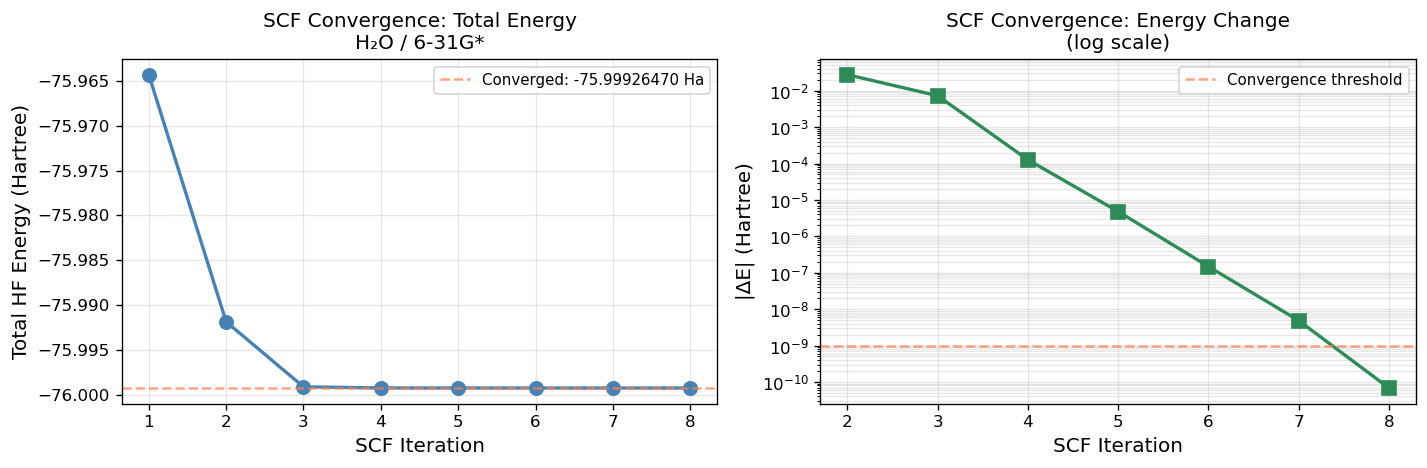


Converged in 8 SCF iterations
Final energy: -75.9992646967 Ha


In [9]:
# ------------------------------------------------------------------
# SCF Convergence Monitoring
# ------------------------------------------------------------------
# PySCF allows us to inject a callback function that is called
# at the end of each SCF iteration.

energies = []
diis_errors = []

def scf_callback(envs):
    """Called after each SCF iteration."""
    energies.append(envs['e_tot'])
    if 'norm_gorb' in envs:
        diis_errors.append(envs['norm_gorb'])

mol = gto.Mole()
mol.atom = 'O 0 0 0; H 0 0.757 -0.469; H 0 -0.757 -0.469'
mol.basis = '6-31g*'
mol.verbose = 0
mol.build()

mf = scf.RHF(mol)
mf.verbose = 0
mf.callback = scf_callback
mf.kernel()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

iterations = list(range(1, len(energies) + 1))

# Panel 1: Total energy vs iteration
ax1.plot(iterations, energies, 'o-', color='steelblue', linewidth=2, markersize=8)
ax1.axhline(y=energies[-1], color='coral', linestyle='--', alpha=0.7,
            label=f'Converged: {energies[-1]:.8f} Ha')
ax1.set_xlabel('SCF Iteration', fontsize=12)
ax1.set_ylabel('Total HF Energy (Hartree)', fontsize=12)
ax1.set_title('SCF Convergence: Total Energy\nH₂O / 6-31G*', fontsize=12)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: Energy change per iteration (log scale)
energy_changes = [abs(energies[i] - energies[i-1]) for i in range(1, len(energies))]
ax2.semilogy(range(2, len(energies)+1), energy_changes, 's-',
             color='seagreen', linewidth=2, markersize=8)
ax2.axhline(y=1e-9, color='coral', linestyle='--', alpha=0.7, label='Convergence threshold')
ax2.set_xlabel('SCF Iteration', fontsize=12)
ax2.set_ylabel('|ΔE| (Hartree)', fontsize=12)
ax2.set_title('SCF Convergence: Energy Change\n(log scale)', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()
print(f"\nConverged in {len(energies)} SCF iterations")
print(f"Final energy: {energies[-1]:.10f} Ha")

##
**For the below calculations, you can also use ../data/sample_inputs/HF_MP2_SP_H2_diss_ORCA.inp file**

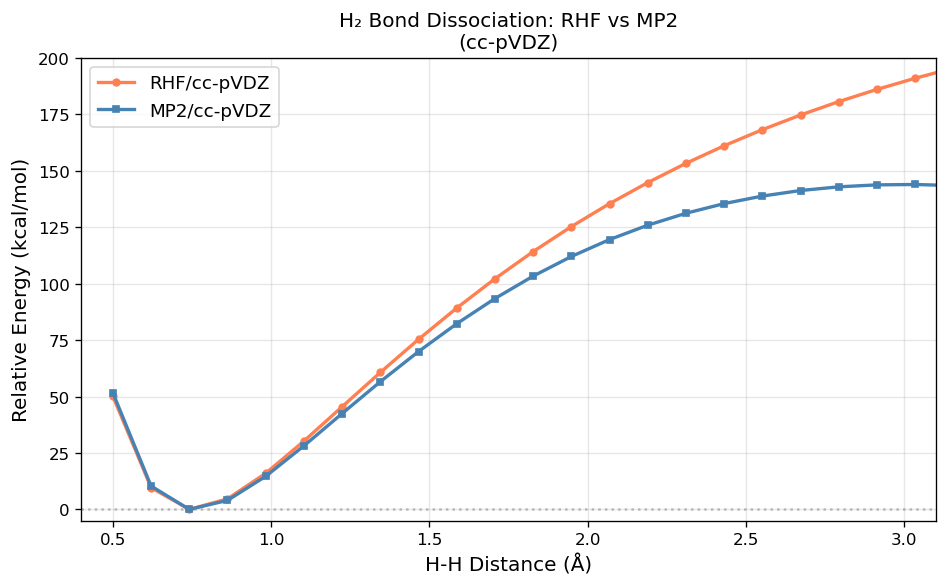

  RHF forces the wavefunction to be a single Slater determinant,
  which cannot properly describe bond breaking.
  At large r(H-H), the true wavefunction should be:
    Ψ ∝ |H↑ H↓⟩ - |H↓ H↑⟩  (purely covalent)
  But RHF gives equal weight to ionic H⁺H⁻ configurations.
CPU times: user 3.91 s, sys: 37.5 ms, total: 3.95 s
Wall time: 1.11 s


In [18]:
%%time
# ------------------------------------------------------------------
# H₂ Bond Dissociation: RHF vs MP2
# ------------------------------------------------------------------
# RHF fails at dissociation because it forces double occupation,
# giving incorrect ionic character (H⁺ + H⁻) at long range.
# MP2 partially corrects this via perturbation theory.

from pyscf import gto, scf, mp

distances = np.linspace(0.5, 4.0, 30)   # Angstroms
e_rhf = []
e_mp2 = []

for d in distances:
    mol = gto.Mole()
    mol.atom = f'H 0 0 0; H 0 0 {d}'
    mol.basis = 'cc-pVDZ'
    mol.verbose = 0
    mol.build()
    
    mf = scf.RHF(mol)
    mf.verbose = 0
    ehf = mf.kernel()
    e_rhf.append(ehf)
    
    # MP2 on top of RHF
    mpt = mp.MP2(mf)
    mpt.verbose = 0
    emp2, _ = mpt.kernel()
    e_mp2.append(ehf + emp2)

e_rhf = np.array(e_rhf)
e_mp2 = np.array(e_mp2)

# Normalize to equilibrium minimum
e_rhf_norm = (e_rhf - e_rhf.min()) * 627.509   # kcal/mol
e_mp2_norm = (e_mp2 - e_mp2.min()) * 627.509

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(distances, e_rhf_norm, 'o-', color='coral', linewidth=2,
        markersize=4, label='RHF/cc-pVDZ')
ax.plot(distances, e_mp2_norm, 's-', color='steelblue', linewidth=2,
        markersize=4, label='MP2/cc-pVDZ')

# Reference: exact 2H dissociation limit
# 2 * E(H atom, UHF) at large distance
ax.axhline(y=0, color='gray', linestyle=':', alpha=0.5)

ax.set_xlabel('H-H Distance (Å)', fontsize=12)
ax.set_ylabel('Relative Energy (kcal/mol)', fontsize=12)
ax.set_title('H₂ Bond Dissociation: RHF vs MP2\n(cc-pVDZ)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0.4, 3.1)
ax.set_ylim(-5, 200)

# Annotate RHF error
ax.annotate('RHF unphysically\nraises at dissociation\n(static correlation error)',
            xy=(3.5, e_rhf_norm[-3]), xytext=(2.5, 50),
            arrowprops=dict(arrowstyle='->', color='coral'),
            fontsize=9, color='coral')

plt.tight_layout()
plt.show()

print("  RHF forces the wavefunction to be a single Slater determinant,")
print("  which cannot properly describe bond breaking.")
print("  At large r(H-H), the true wavefunction should be:")
print("    Ψ ∝ |H↑ H↓⟩ - |H↓ H↑⟩  (purely covalent)")
print("  But RHF gives equal weight to ionic H⁺H⁻ configurations.")

Koopmans' Theorem: HF/6-31G* Ionization Energies
Molecule  Computed IE (eV)  Experimental IE (eV)  Error (eV)
     H2O             13.57                 12.62        0.95
     NH3             11.47                 10.07        1.40
      CO             14.90                 14.01        0.89
      HF             17.10                 16.03        1.07
      N2             16.63                 15.58        1.05

Mean Absolute Error: 1.07 eV


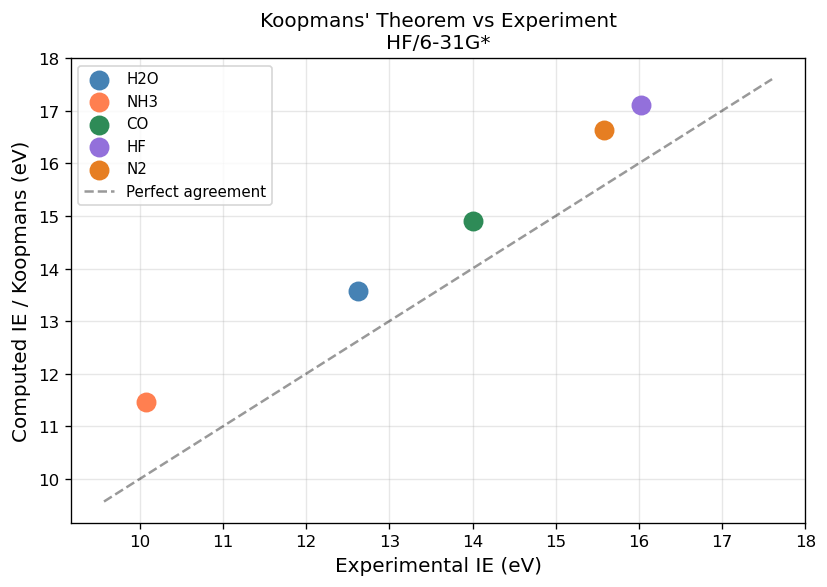

CPU times: user 1.9 s, sys: 27.8 ms, total: 1.92 s
Wall time: 777 ms


In [16]:
%%time
# ------------------------------------------------------------------
# Koopmans' Theorem: IE ≈ -ε_HOMO
# ------------------------------------------------------------------
# Compare predicted ionization energies (-HOMO energy) with experiment

molecules_IE = {
    'H2O':  ('O 0 0 0; H 0 0.757 -0.469; H 0 -0.757 -0.469', 12.62),
    'NH3':  ('N 0 0 0.116; H 0 0.939 -0.269; H 0.814 -0.469 -0.269; H -0.814 -0.469 -0.269', 10.07),
    'CO':   ('C 0 0 0; O 0 0 1.128', 14.01),
    'HF':   ('H 0 0 0; F 0 0 0.917', 16.03),
    'N2':   ('N 0 0 0; N 0 0 1.098', 15.58),
}

koopman_results = []
for name, (atom_str, exp_ie) in molecules_IE.items():
    mol = gto.Mole()
    mol.atom = atom_str
    mol.basis = '6-31g*'
    mol.verbose = 0
    mol.build()
    
    mf = scf.RHF(mol)
    mf.verbose = 0
    mf.kernel()
    
    mo_e = mf.mo_energy
    mo_occ = mf.mo_occ
    homo_idx = np.where(mo_occ > 0)[0][-1]
    comp_ie = -mo_e[homo_idx] * 27.2114
    
    koopman_results.append({
        'Molecule': name,
        'Computed IE (eV)': round(comp_ie, 2),
        'Experimental IE (eV)': exp_ie,
        'Error (eV)': round(comp_ie - exp_ie, 2),
    })

df_k = pd.DataFrame(koopman_results)
print("Koopmans' Theorem: HF/6-31G* Ionization Energies")
print(df_k.to_string(index=False))

mae = np.mean(np.abs(df_k['Error (eV)']))
print(f"\nMean Absolute Error: {mae:.2f} eV")

# Plot
fig, ax = plt.subplots(figsize=(7, 5))
x = np.array(df_k['Experimental IE (eV)'])
y = np.array(df_k['Computed IE (eV)'])
names = list(df_k['Molecule'])

colors_mol = ['steelblue', 'coral', 'seagreen', 'mediumpurple', '#E67E22']
for xi, yi, name, col in zip(x, y, names, colors_mol):
    ax.scatter(xi, yi, color=col, s=120, zorder=5, label=name)

# y=x line (perfect agreement)
lim_min = min(min(x), min(y)) - 0.5
lim_max = max(max(x), max(y)) + 0.5
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'k--', alpha=0.4, label='Perfect agreement')

ax.set_xlabel('Experimental IE (eV)', fontsize=12)
ax.set_ylabel('Computed IE / Koopmans (eV)', fontsize=12)
ax.set_title("Koopmans' Theorem vs Experiment\nHF/6-31G*", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 🔬 Research Connection

Hartree-Fock theory, despite its limitations, remains fundamental:

- **Starting point for coupled cluster**: CCSD(T), the "gold standard" of quantum chemistry,
  builds on HF via perturbation theory and cluster operators

  **Also a good initialization point to explore the complete active space (CAS) calculations,
  like number of orbitals, electrons required for CAS treatment.**
  
- **HF in DFT**: The Kohn-Sham equations have the same structure as HF, but replace
  the exact exchange with an approximate exchange-correlation functional.
- **Orbital analysis**: HF molecular orbitals (sigma, pi, lone pairs) provide chemical
  intuition used daily in organic and organometallic chemistry.
- **Limitations drive innovation**: The failures of HF (correlation energy, dispersion,
  open-shell systems) motivated the entire field of post-HF and DFT methods.

**Read more:** Roothaan, C.C.J. (1951). *Rev. Mod. Phys.* **23**, 69, https://doi.org/10.1103/RevModPhys.23.69 — derived
the matrix HF equations (Roothaan equations) that all modern QC codes implement.

## 📋 Summary

| Concept | Key Result |
|---------|----------|
| Slater determinant | Antisymmetric wavefunction for N fermions; incorporates Pauli principle |
| Fock operator | $\hat{F} = \hat{h} + \hat{J} - \hat{K}$; mean-field treatment of e-e repulsion |
| SCF procedure | Iterative diagonalization until density matrix converges |
| Koopmans' theorem | $\text{IE} \approx -\epsilon_{HOMO}$; error ~0.5-1.5 eV for typical molecules |
| HF correlation energy | $E_{corr} = E_{exact} - E_{HF} \approx$ -0.5 to -1.5 eV/electron pair |
| H₂ dissociation | RHF fails; needs multi-reference methods or UHF |

**Post-HF hierarchy** (increasing accuracy, increasing cost):
HF → MP2 → CCSD → CCSD(T) → FCI

**DFT alternative** (similar cost to HF, better accuracy):
DFT captures ~80-90% of correlation energy implicitly through $E_{xc}$

## 📝 Exercises

1. **Basis set effect on Koopmans'**: Redo the Koopmans' theorem calculation using
   `def2-TZVP` instead of `6-31G*`. Does a larger basis set improve agreement with
   experiment? Why or why not?

2. **SCF starting point**: Try using `mf.init_guess = 'atom'` vs `mf.init_guess = 'huckel'`
   for the water SCF calculation. Does the starting guess affect the converged energy?
   Does it affect the number of iterations?

3. **Open-shell HF**: CO has a singlet ground state. Run UHF (unrestricted HF) on 
   the triplet state of CO using `mol.spin = 2` and `scf.UHF(mol)`.
   What is the energy difference between singlet and triplet?

4. **HOMO-LUMO gap trends**: Compute HF/6-31G* HOMO-LUMO gaps for 
   ethylene (C₂H₄), butadiene (C₄H₆), hexatriene (C₆H₈), and benzene (C₆H₆).
   Plot gap vs number of double bonds. What trend do you observe?

5. **Correlation energy estimate**: Compute RHF and MP2 energies for H₂O with cc-pVTZ.
   What fraction of the correlation energy does MP2 recover (compared to ~-0.37 Ha
   for the experimental correlation energy of water)?

---

# 03 — DFT Fundamentals: From Hohenberg-Kohn to Modern Functionals

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/notebooks/03_dft_fundamentals.ipynb)

## 🎯 Learning Objectives

- The two Hohenberg-Kohn theorems
- The Kohn-Sham DFT formalism and its connection to HF
- Exchange-correlation (XC) functionals on Jacob's Ladder
- LDA, GGA, meta-GGA, hybrid, and double-hybrid functionals
- Dispersion corrections (DFT-D3, D4)
- How to choose an appropriate functional for a given chemical problem

## Theory: From Density to Energy

### 3.1 Hohenberg-Kohn Theorems (1964)

DFT is built on two exact theorems by Hohenberg and Kohn:

**Theorem 1 (Existence):** The external potential $v_{ext}(\mathbf{r})$ — and hence the
total energy — is a unique functional of the ground-state electron density $n_0(\mathbf{r})$:

$$E = E[n_0]$$

**Theorem 2 (Variational principle):** The universal functional $F[n]$ delivers
the ground-state energy if and only if the true ground-state density is used:

$$E[n] \geq E_0 \quad \text{for all } n \neq n_0$$

These theorems establish that $n(\mathbf{r})$ — a function of only 3 spatial variables
— contains all information needed to determine the ground-state energy.

### 3.2 Kohn-Sham DFT (1965)

The practical implementation by Kohn and Sham introduces a fictitious non-interacting
reference system with the **same density** as the real interacting system.

The Kohn-Sham equations are:

$$\left[-\frac{1}{2}\nabla^2 + v_{eff}(\mathbf{r})\right]\phi_i(\mathbf{r}) = \epsilon_i \phi_i(\mathbf{r})$$

where the effective potential is:

$$v_{eff}(\mathbf{r}) = v_{ext}(\mathbf{r}) + \underbrace{\int \frac{n(\mathbf{r}')}{|\mathbf{r}-\mathbf{r}'|} d\mathbf{r}'}_{v_{Hartree}} + \underbrace{v_{xc}[n](\mathbf{r})}_{exchange-correlation}$$

The total DFT energy is:

$$E_{KS}[n] = T_s[n] + E_{ne}[n] + J[n] + E_{xc}[n]$$

where $T_s$ = kinetic energy of non-interacting electrons, $E_{ne}$ = nuclear-electron
attraction, $J$ = classical Coulomb (Hartree) energy, and $E_{xc}$ = exchange-correlation energy.

### 3.3 The Exchange-Correlation Functional

The exact $E_{xc}[n]$ is unknown. All DFT methods differ in how they approximate it.

$$E_{xc}[n] = E_x[n] + E_c[n]$$

**Exchange energy** $E_x$ accounts for the Fermi hole (Pauli antisymmetry),
**correlation energy** $E_c$ captures dynamic and static electron correlation.

### 3.4 Dispersion Interactions

Standard DFT functionals miss long-range London dispersion ($r^{-6}$ decay).
The DFT-D3 correction by Grimme adds:

$$E_{DFT-D3} = -\frac{1}{2}\sum_{i\neq j} s_6 \frac{C_6^{ij}}{r_{ij}^6} f_{damp}(r_{ij}) + s_8 \frac{C_8^{ij}}{r_{ij}^8} f_{damp}(r_{ij})$$

Use keywords in ORCA: `B3LYP-D3BJ/def2-SVP` or `PBE0-D3/def2-TZVP`

/tmp/ipykernel_4041972/2473571662.py:85: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


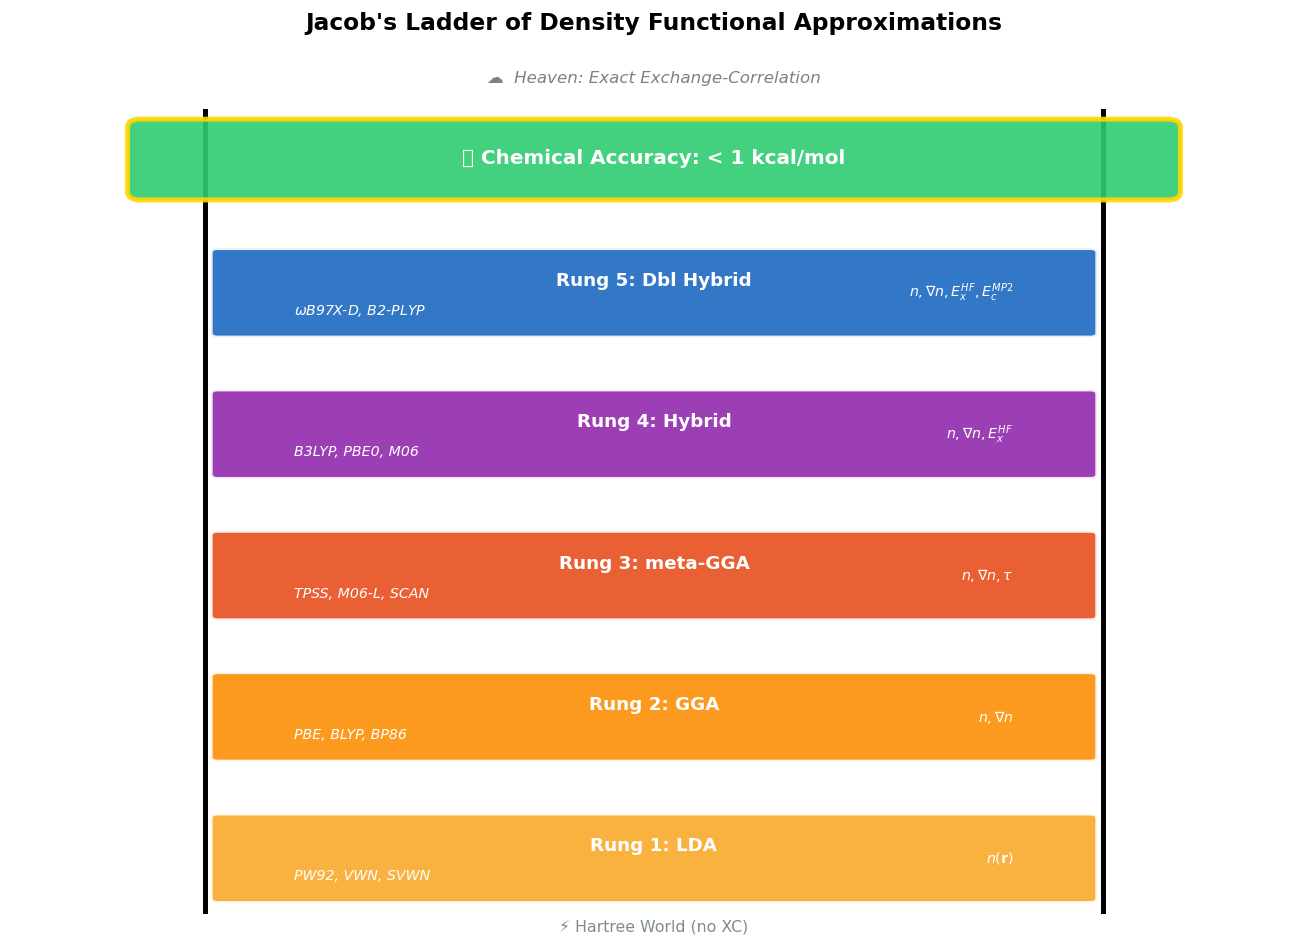

In [20]:
# =============================================================================
# Ch121a: Quantum Chemistry & DFT — Notebook 03: DFT Fundamentals
# License: GPL-3.0 (https://www.gnu.org/licenses/gpl-3.0.en.html)
# =============================================================================
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from pyscf import gto, dft, scf

# ------------------------------------------------------------------
# Jacob's Ladder of DFT Approximations
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis('off')

# Color gradient from bottom (warm) to top (cool)
rung_colors = ['#F9A825', '#FB8C00', '#E64A19', '#8E24AA', '#1565C0']
rung_data = [
    (1, 'Rung 1: LDA',      'Local Density\nApproximation',
     'PW92, VWN, SVWN',      r'$n(\mathbf{r})$'),
    (2, 'Rung 2: GGA',       'Generalized Gradient\nApproximation',
     'PBE, BLYP, BP86',       r'$n, \nabla n$'),
    (3, 'Rung 3: meta-GGA',  'Kinetic Energy Density',
     'TPSS, M06-L, SCAN',     r'$n, \nabla n, \tau$'),
    (4, 'Rung 4: Hybrid',    'Exact HF Exchange\n(partial)',
     'B3LYP, PBE0, M06',      r'$n, \nabla n, E_x^{HF}$'),
    (5, 'Rung 5: Dbl Hybrid','HF Exchange + MP2\nCorrelation',
     r'$\omega$B97X-D, B2-PLYP',r'$n, \nabla n, E_x^{HF}, E_c^{MP2}$'),
]

# Draw ladder poles
ax.plot([1.5, 1.5], [0.3, 10.2], 'k-', lw=3, zorder=1)
ax.plot([8.5, 8.5], [0.3, 10.2], 'k-', lw=3, zorder=1)

for (rung_num, title, subtitle, functionals, ingredients) in rung_data:
    y_center = rung_num * 1.75 - 0.8
    color = rung_colors[rung_num - 1]
    
    # Rung (horizontal bar)
    rung_patch = mpatches.FancyBboxPatch((1.6, y_center - 0.5), 6.8, 1.0,
                                          boxstyle="round,pad=0.05",
                                          facecolor=color, edgecolor='white',
                                          linewidth=2, alpha=0.88, zorder=2)
    ax.add_patch(rung_patch)
    
    # Title text
    ax.text(5.0, y_center + 0.15, title, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', zorder=3)
    
    # Functional examples (left)
    ax.text(2.2, y_center - 0.22, functionals, ha='left', va='center',
            fontsize=8.5, color='white', zorder=3, style='italic')
    
    # Ingredients (right)
    ax.text(7.8, y_center, ingredients, ha='right', va='center',
            fontsize=8.5, color='white', zorder=3)

# 'Chemical Accuracy' bar at top
ca_patch = mpatches.FancyBboxPatch((1.0, 9.2), 8.0, 0.8,
                                    boxstyle="round,pad=0.1",
                                    facecolor='#2ECC71', edgecolor='gold',
                                    linewidth=3, alpha=0.9, zorder=2)
ax.add_patch(ca_patch)
ax.text(5.0, 9.62, '🎯 Chemical Accuracy: < 1 kcal/mol',
        ha='center', va='center', fontsize=12, fontweight='bold',
        color='white', zorder=3)

# 'Heaven' / exact label
ax.text(5.0, 10.6, '☁  Heaven: Exact Exchange-Correlation',
        ha='center', va='center', fontsize=10, color='gray', style='italic')

# Ground label
ax.text(5.0, 0.1, '⚡ Hartree World (no XC)',
        ha='center', va='center', fontsize=9.5, color='#7F8C8D')

# Title
ax.set_title("Jacob's Ladder of Density Functional Approximations",
             fontsize=14, fontweight='bold', pad=10)

plt.tight_layout()
plt.show()

## I rendered the above but I like this below one more from 
**Best-Practice DFT Protocols for Basic Molecular Computational Chemistry**, Bursch et al. 
https://doi.org/10.1002/anie.202205735 Open access, **Very important work** 
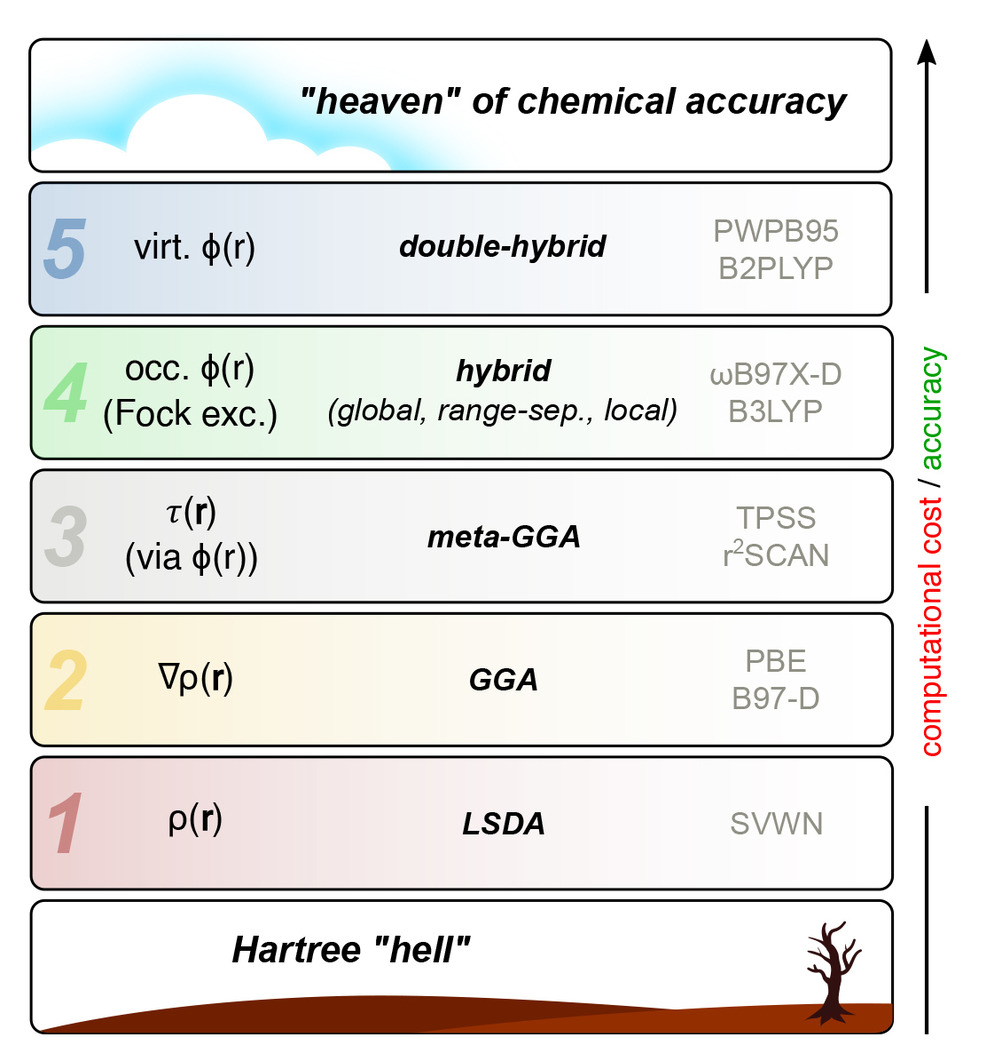

  SVWN     (LDA       ): E = -75.795146 Ha  μ = 2.024 D
  PBE      (GGA       ): E = -76.271966 Ha  μ = 1.935 D
  TPSS     (meta-GGA  ): E = -76.360001 Ha  μ = 1.936 D
  B3LYP    (Hybrid    ): E = -76.358122 Ha  μ = 1.981 D
  PBE0     (Hybrid    ): E = -76.276252 Ha  μ = 2.009 D


Functional Category  Energy (Ha)  Dipole (D)
      SVWN      LDA   -75.795146       2.024
       PBE      GGA   -76.271966       1.935
      TPSS meta-GGA   -76.360001       1.936
     B3LYP   Hybrid   -76.358122       1.981
      PBE0   Hybrid   -76.276252       2.009


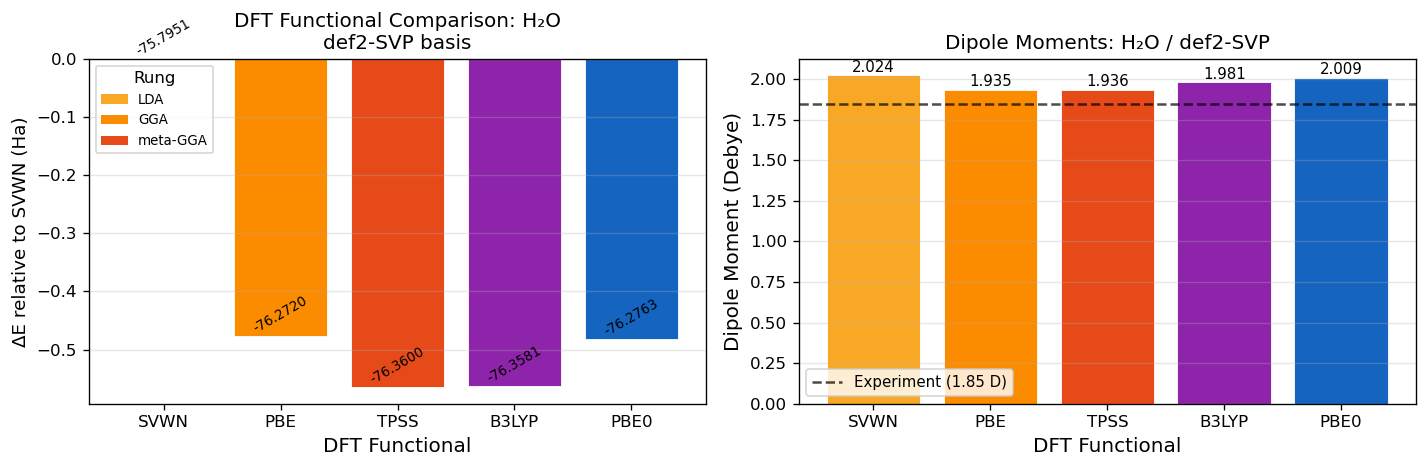

CPU times: user 32 s, sys: 55.8 ms, total: 32.1 s
Wall time: 8.72 s


In [21]:
%%time
# ------------------------------------------------------------------
# DFT Functional Comparison on H₂O / def2-SVP
# ------------------------------------------------------------------

mol = gto.Mole()
mol.atom = '''O  0.000000  0.000000  0.117176
H  0.000000  0.757001 -0.468704
H  0.000000 -0.757001 -0.468704'''
mol.basis = 'def2-SVP'
mol.verbose = 0
mol.build()

functionals = {
    'SVWN':  ('LDA',       '#F9A825'),
    'PBE':   ('GGA',       '#FB8C00'),
    'TPSS':  ('meta-GGA',  '#E64A19'),
    'B3LYP': ('Hybrid',    '#8E24AA'),
    'PBE0':  ('Hybrid',    '#1565C0'),
}

results = []
for func, (category, color) in functionals.items():
    mf = dft.RKS(mol)
    mf.xc = func
    mf.verbose = 0
    e = mf.kernel()
    dm = mf.make_rdm1()
    dip = mf.dip_moment(mol, dm, verbose=0)
    dip_mag = np.linalg.norm(dip)
    results.append({
        'Functional': func, 'Category': category,
        'Energy (Ha)': round(e, 6), 'Dipole (D)': round(dip_mag, 3),
        'Color': color
    })
    print(f"  {func:8s} ({category:10s}): E = {e:.6f} Ha  μ = {dip_mag:.3f} D")

df = pd.DataFrame(results)
print("\n")
print(df[['Functional','Category','Energy (Ha)','Dipole (D)']].to_string(index=False))

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Panel 1: Total energies
energies = df['Energy (Ha)'].values
funcs = df['Functional'].values
colors_list = df['Color'].values

bars1 = ax1.bar(funcs, energies - energies.max(), color=colors_list,
                edgecolor='white', linewidth=0.5)
ax1.set_xlabel('DFT Functional', fontsize=12)
ax1.set_ylabel('ΔE relative to SVWN (Ha)', fontsize=11)
ax1.set_title('DFT Functional Comparison: H₂O\ndef2-SVP basis', fontsize=12)
ax1.grid(True, alpha=0.3, axis='y')
for bar, e in zip(bars1, energies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
             f'{e:.4f}', ha='center', va='bottom', fontsize=8, rotation=30)

# Panel 2: Dipole moments
dipoles = df['Dipole (D)'].values
bars2 = ax2.bar(funcs, dipoles, color=colors_list, edgecolor='white', linewidth=0.5)
ax2.axhline(y=1.85, color='black', linestyle='--', alpha=0.7, label='Experiment (1.85 D)')
ax2.set_xlabel('DFT Functional', fontsize=12)
ax2.set_ylabel('Dipole Moment (Debye)', fontsize=12)
ax2.set_title('Dipole Moments: H₂O / def2-SVP', fontsize=12)
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
for bar, d in zip(bars2, dipoles):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{d:.3f}', ha='center', va='bottom', fontsize=9)

# Add category labels
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F9A825', label='LDA'),
    Patch(facecolor='#FB8C00', label='GGA'),
    Patch(facecolor='#E64A19', label='meta-GGA'),
    Patch(facecolor='#8E24AA', label='Hybrid'),
    Patch(facecolor='#1565C0', label='Hybrid'),
]
ax1.legend(handles=legend_elements[:3], fontsize=8, title='Rung')

plt.tight_layout()
plt.show()

In [ ]:
# ------------------------------------------------------------------
# DFT-D3 Dispersion Correction
# ------------------------------------------------------------------
# Standard DFT functionals miss van der Waals / London dispersion
# interactions. Grimme's DFT-D3 correction adds pairwise C6/r^6 terms.

import numpy as np
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt

# Conceptual: Lennard-Jones-like comparison
r = np.linspace(2.5, 12, 500)   # Angstrom

# Approximate DFT (no dispersion) for benzene dimer: flat near repulsion, no well
def dft_nodispersion(r):
    # Simplified: Pauli repulsion only, very shallow
    return 5.0 * np.exp(-r/1.5) - 0.2 * np.exp(-r/4.0)

# With D3 correction: adds -C6/r^6 term
def dft_d3(r, C6=45.0, s6=1.0):
    return dft_nodispersion(r) - s6 * C6 / r**6

E_nodis = dft_nodispersion(r)
E_d3 = dft_d3(r)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(r, E_nodis, '--', color='coral', linewidth=2.5, label='DFT (no dispersion)')
ax.plot(r, E_d3, '-', color='steelblue', linewidth=2.5, label='DFT-D3')
ax.axhline(y=0, color='gray', linewidth=0.8, linestyle=':', alpha=0.7)
ax.fill_between(r, E_d3, 0, where=(E_d3 < 0), alpha=0.15, color='steelblue',
                label='Dispersion well')
ax.set_xlim(2.5, 12)
ax.set_ylim(-0.6, 1.0)
ax.set_xlabel('Intermolecular Distance (Å)', fontsize=12)
ax.set_ylabel('Interaction Energy (kcal/mol)', fontsize=12)
ax.set_title('Effect of DFT-D3 Dispersion Correction\n(Conceptual: benzene dimer)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("DFT-D3 Dispersion Correction Summary:")
print("  ΔE_disp = -Σ_{i<j} s₆ C₆ᵢʲ/r₆ + s₈ C₈ᵢʲ/r₈  (with damping function)")
print()
print("Usage in PySCF:")
print("  mf = dft.RKS(mol)")
print("  mf.xc = 'B3LYP'")
print("  from pyscf import dftd3  # requires dftd3 Python bindings")
print("  mf = dftd3.dftd3(mf)    # wraps mf with D3 correction")
print()
print("Usage in ORCA:")
print("  ! B3LYP-D3BJ def2-SVP Opt")
print("  ! PBE0-D3/def2-TZVP Energy")
print()
print("Common dispersion variants:")
print("  -D3(BJ): Becke-Johnson damping (recommended for most systems)")
print("  -D3(0):  Zero-damping (Grimme 2010, original)")
print("  -D4:     Charge-dependent, more accurate for ionic systems")

## 2. DFT Functional Reference Table

| Functional | Type | %HF Exchange | Dispersion | Cost | Accuracy | Good For | Caution |
|------------|------|:---:|:---:|:---:|:---:|---------|----------|
| SVWN | LDA | 0 | ✗ | ★ | ★★ | Solids, quick tests | Overbinds molecules |
| PBE | GGA | 0 | ✗ | ★★ | ★★★ | Solids, surfaces | Self-interaction |
| BLYP | GGA | 0 | ✗ | ★★ | ★★★ | Organics | Dispersion missing |
| TPSS | meta-GGA | 0 | ✗ | ★★★ | ★★★ | General chemistry | Slow |
| M06-L | meta-GGA | 0 | ✗ | ★★★ | ★★★★ | Transition metals | Sensitive to grid |
| B3LYP | Hybrid | 20 | ✗ | ★★★ | ★★★★ | Organics, pharmacy | No dispersion; fails TM |
| B3LYP-D3 | Hybrid+D | 20 | ✓ | ★★★ | ★★★★ | General organics | TM still tricky |
| PBE0 | Hybrid | 25 | ✗ | ★★★ | ★★★★ | General chemistry | Dispersion missing |
| PBE0-D3 | Hybrid+D | 25 | ✓ | ★★★ | ★★★★★ | **Recommended** | |
| r2scan-3c | Composite meta-GGA |  | ✓ | ★★★ | ★★★★★ | **Recommended** | |
| TPSSh | Hybrid | 10 | ✗ | ★★★ | ★★★★ | Transition metals | |
| M06 | Hybrid | 27 | ✗ | ★★★★ | ★★★★ | Main group + TM | Sensitive to grid |
| M06-2X | Hybrid | 54 | ✗ | ★★★★ | ★★★★★ | Thermochem, kinetics | Fails for TM |
| ωB97X-D | Range-sep | var | ✓ | ★★★★ | ★★★★★ | CT excitations, NCI | Expensive |
| CAM-B3LYP | Range-sep | var | ✗ | ★★★★ | ★★★★ | CT, long-range | |
| B2-PLYP | Double hybrid | 53 | ✗ | ★★★★★ | ★★★★★ | High accuracy | Very expensive |

_One favorite paper_ 
**Best-Practice DFT Protocols for Basic Molecular Computational Chemistry**, Bursch et al. 
https://doi.org/10.1002/anie.202205735 Open access 

**Some recommendations:**
- **Geometry optimization**: `B3LYP/def2-SVP` or `r2scan-3c/def2-SVP`
- **Reaction Energies**: `ωB97 (X/V/M/D4) variants - def2-QZVP` or `r2scan-3c/def2-TZVP`
- **Transition metals**: `TPSSh/def2-SVP` or `M06/def2-SVP`
- **Excited states**: `CAM-B3LYP/def2-SVP` (TD-DFT)

## 🔬 Research Connection

DFT is the workhorse of modern computational chemistry and materials science:

- **~50% of all computational chemistry papers** use DFT (B3LYP alone has >100,000 citations)
- **Drug design**: DFT computes binding site interactions, reaction mechanisms in metalloenzymes
- **Heterogeneous catalysis**: PBE/plane-waves for surface reactions (e.g., CO₂ reduction)
- **Battery materials**: DFT predicts lithium intercalation energies in electrode materials
- **Nobel Prizes**: Kohn (1998 Chemistry), Karplus/Levitt/Warshel (2013 Chemistry)

**The DFT accuracy crisis**: B3LYP was found to fail for dispersion-dominated systems,
kinetics (reaction barriers), and transition metal complexes. This drove development
of M06-2X, ωB97X-D, and dispersion corrections, now standard in publications.

## 📋 Summary

| Concept | Key Points |
|---------|----------|
| HK Theorem 1 | Ground state energy is a unique functional of $n_0(\mathbf{r})$ |
| HK Theorem 2 | Variational principle: true $n_0$ minimizes $E[n]$ |
| Kohn-Sham DFT | Non-interacting reference with same density; same structure as HF |
| LDA | Uses only $n(\mathbf{r})$; overbinds; good for solids |
| GGA | Adds $\nabla n$; better for molecules; missing dispersion |
| Hybrid | Mixes HF exchange; best for most molecular applications |
| Dispersion | -D3(BJ) adds $C_6/r^6$ correction; always use for weak interactions |

**When DFT works well:** Geometries (±0.01-0.02 Å), reaction energies (±2 kcal/mol),
vibrational frequencies, dipole moments, NMR shifts

**When DFT struggles:** Strong correlation (multi-reference), charge-transfer excitations (without range-separation), dispersion (without correction), delocalization error

## 📝 Exercises

1. **Jacob's Ladder**: For each rung (LDA, GGA, meta-GGA, hybrid), name one functional
   not listed in the notebook. Look up its year of publication and the journal it appeared in.

2. **Functional comparison**: Run the water functional comparison with `aug-cc-pVTZ`
   instead of `def2-SVP`. Does the ordering of energies change? Why might it?

3. **Dispersion in benzene dimer**: Using PySCF, compute the interaction energy of
   two benzene molecules (face-to-face at 3.8 Å) with B3LYP/6-31G* (no dispersion).
   What sign is the interaction? Is this physical?

4. **Exact exchange fraction**: B3LYP uses 20% HF exchange. Try changing this using
   `mf.xc = '0.15*HF + 0.85*B88, LYP'` and `mf.xc = '0.30*HF + 0.70*B88, LYP'`.
   How do the energy and dipole moment of water change?

5. **DFT vs HF correlation energy**: Compare the energy of H₂O computed by
   RHF/def2-SVP and PBE/def2-SVP. The difference approximates how much correlation
   energy DFT captures. How does this compare to the MP2 correlation energy?